In [1]:
import pandas as pd
import numpy as np

In [ ]:
df_clean = pd.read_csv("../data/processed/HHS_Clean_Dataset.csv")

df_clean["Date"] = pd.to_datetime(df_clean["Date"])

df_clean = df_clean.sort_values("Date")

df_clean = df_clean.set_index("Date")

print(df_clean.index.day_name().value_counts().sort_index())

Date
Friday         2
Monday       142
Sunday       127
Thursday     145
Tuesday      146
Wednesday    144
Name: count, dtype: int64


In [3]:
missing_dates = pd.date_range(
    start=df_clean.index.min(),
    end=df_clean.index.max(),
    freq="D"
).difference(df_clean.index)

missing_df = pd.DataFrame({"Missing_Date": missing_dates})
missing_df["Weekday"] = missing_df["Missing_Date"].dt.day_name()

print(missing_df["Weekday"].value_counts())

Weekday
Saturday     150
Friday       148
Sunday        23
Monday         7
Thursday       5
Wednesday      5
Tuesday        3
Name: count, dtype: int64


In [5]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(df_clean["Children in HHS Care"])

print("ADF Statistic:", result[0])
print("p-value:", result[1])

if result[1] < 0.05:
    print("Stationary")
else:
    print("Not Stationary")

ADF Statistic: -0.9421281059536994
p-value: 0.7737827598666875
Not Stationary


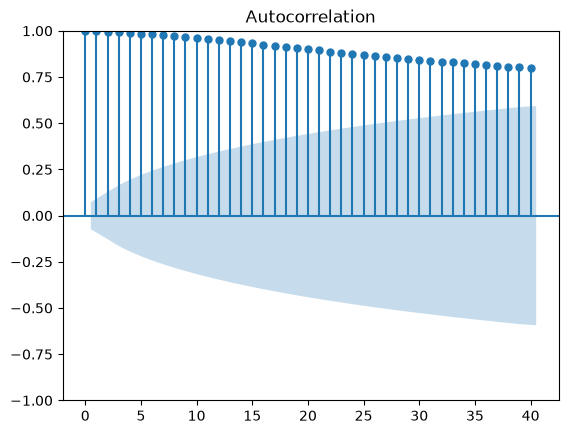

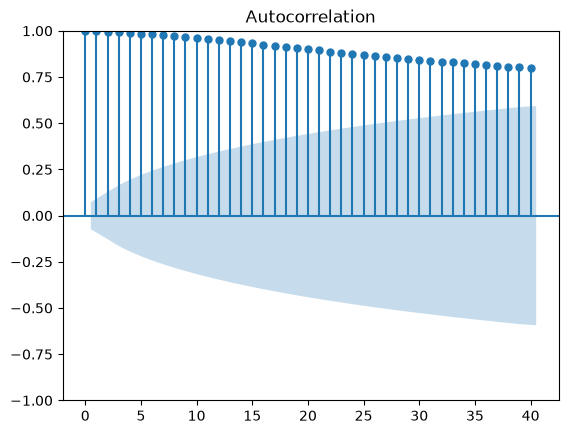

In [6]:
from statsmodels.graphics.tsaplots import plot_acf

plot_acf(df_clean["Children in HHS Care"], lags=40)

In [8]:
train_size = int(len(df_clean) * 0.8)

train = df_clean.iloc[:train_size]
test = df_clean.iloc[train_size:]

In [9]:
test["Naive_Prediction"] = train["Children in HHS Care"].iloc[-1]

C:\Users\HP\AppData\Local\Temp\ipykernel_12696\3040892311.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test["Naive_Prediction"] = train["Children in HHS Care"].iloc[-1]


In [10]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error
)
import numpy as np

mae = mean_absolute_error(
    test["Children in HHS Care"],
    test["Naive_Prediction"]
)

rmse = np.sqrt(
    mean_squared_error(
        test["Children in HHS Care"],
        test["Naive_Prediction"]
    )
)

mape = mean_absolute_percentage_error(
    test["Children in HHS Care"],
    test["Naive_Prediction"]
)

print("MAE :", mae)
print("RMSE:", rmse)
print("MAPE:", mape)

MAE : 196.09154929577466
RMSE: 239.3515447450277
MAPE: 0.0923834076410308


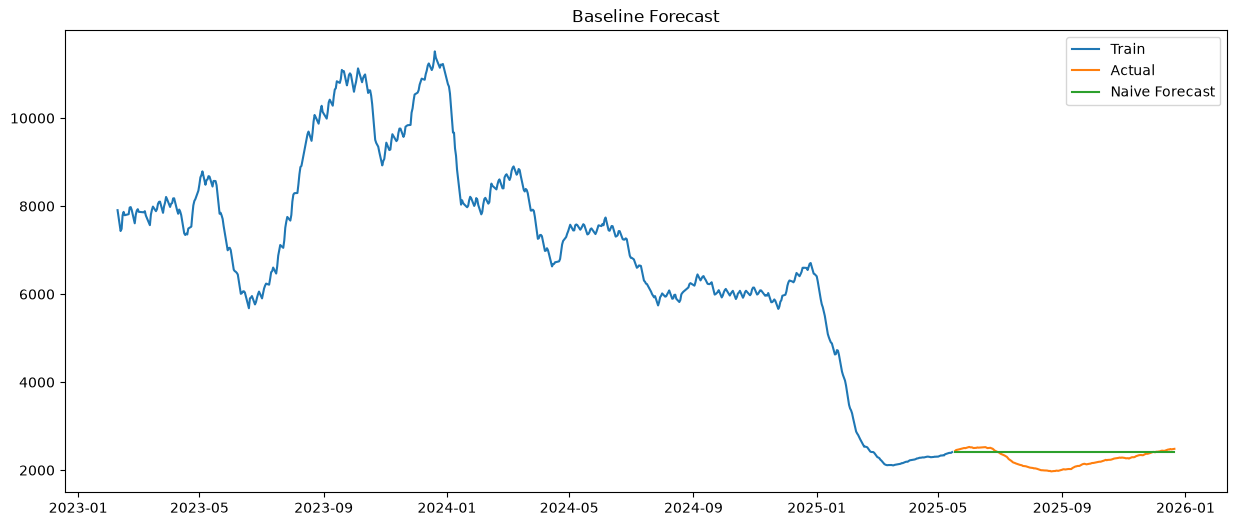

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15,6))

plt.plot(
    train.index,
    train["Children in HHS Care"],
    label="Train"
)

plt.plot(
    test.index,
    test["Children in HHS Care"],
    label="Actual"
)

plt.plot(
    test.index,
    test["Naive_Prediction"],
    label="Naive Forecast"
)

plt.title("Baseline Forecast")
plt.legend()

plt.show()

In [13]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(df_clean["Children in HHS Care"])

print("ADF Statistic:", result[0])
print("P-value:", result[1])

ADF Statistic: -0.9421281059536994
P-value: 0.7737827598666875
